In [11]:
# For each theta in {-3, -2, -1, 0, 1, 2, 3}, forward the trained DQN with
# state=[theta] and inspect the top-5% / bottom-5% items ranked by Q value:
#   * item parameters (a, b, c)
#   * 3PL Fisher information at that theta
# Repeated for the EAP_unif and MLE checkpoints.
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for root in [cwd, *cwd.parents]:
        if (root / "data").is_dir() and (root / "EXP027").is_dir():
            return root
    raise FileNotFoundError("Run this notebook inside the repository.")


ROOT = find_project_root()
EXP027_DIR = ROOT / "EXP027"
MODEL_DIR = EXP027_DIR / "models"
RESULTS_DIR = EXP027_DIR / "results"

device = torch.device("cpu")

# Config aligned with EXP027 DQN training notebook.
INPUT_SIZE = 1
FIRST_HIDDEN = 50
SECOND_HIDDEN = 30
ACTION_SPACE = 500
DROPOUT_RATE = 0.0

BANK_TYPE = "uncor"
BANK_ID = 1
GAMMA = "0.1"
THETAS = [-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0]
TOP_FRAC = 0.05  # top 5% and bottom 5% of Q values

print(f"Project root : {ROOT}")
print(f"Model dir    : {MODEL_DIR}")
print(f"Bank         : {BANK_TYPE}_{BANK_ID}")
print(f"Thetas       : {THETAS}")
print(f"Top/bottom % : {TOP_FRAC:.0%}")

Project root : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History
Model dir    : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP027/models
Bank         : uncor_1
Thetas       : [-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0]
Top/bottom % : 5%


In [12]:
class Net(nn.Module):
    def __init__(
        self, input_size, first_hidden, second_hidden, action_space, dropout_rate
    ):
        super().__init__()
        self.fc1 = nn.Linear(input_size, first_hidden)
        self.fc2 = nn.Linear(first_hidden, second_hidden)
        self.out = nn.Linear(second_hidden, action_space)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = self.dropout(self.fc1(x))
        x = F.relu(x)
        x = self.dropout(self.fc2(x))
        x = F.relu(x)
        return self.out(x)


def load_model(path: Path) -> Net:
    model = Net(INPUT_SIZE, FIRST_HIDDEN, SECOND_HIDDEN, ACTION_SPACE, DROPOUT_RATE).to(
        device
    )
    state_dict = torch.load(path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model.eval()
    return model


def FI(item_para: np.ndarray, theta: float, D: float = 1.0) -> np.ndarray:
    a = item_para[:, 0]
    b = item_para[:, 1]
    c = item_para[:, 2]
    return (
        D**2
        * a**2
        * (1 - c)
        / (c + np.exp(D * a * (theta - b)))
        / (1 + np.exp(-D * a * (theta - b))) ** 2
    )


bank_path = (
    ROOT / "data" / "uncorrelated_banks" / f"item_bank_{BANK_TYPE}_{BANK_ID}.csv"
)
item_bank_df = pd.read_csv(bank_path)[["a", "b", "c"]]
item_bank = item_bank_df.to_numpy()
assert item_bank.shape[0] == ACTION_SPACE

models = {
    "EAP_unif": load_model(
        MODEL_DIR / f"dqn_EAP_unif_{BANK_TYPE}_{BANK_ID}_gamma_{GAMMA}.pt"
    ),
    "MLE": load_model(MODEL_DIR / f"dqn_MLE_{BANK_TYPE}_{BANK_ID}_gamma_{GAMMA}.pt"),
}

print(f"item bank : {item_bank.shape}  (from {bank_path.name})")
print(f"models    : {list(models.keys())}")

item bank : (500, 3)  (from item_bank_uncor_1.csv)
models    : ['EAP_unif', 'MLE']


In [13]:
# Analysis: for each (model, theta), rank items by Q(state=[theta]) and take
# top / bottom TOP_FRAC. Report parameter and Fisher-information statistics.
def q_values(model: Net, theta: float) -> np.ndarray:
    state = torch.tensor([[theta]], dtype=torch.float32, device=device)
    with torch.no_grad():
        q = model(state).cpu().numpy().flatten()
    return q


def describe_group(item_bank: np.ndarray, fi: np.ndarray, idx: np.ndarray) -> dict:
    subset = item_bank[idx]
    fi_subset = fi[idx]
    return {
        "n": len(idx),
        "a_mean": subset[:, 0].mean(),
        "a_std": subset[:, 0].std(ddof=1),
        "b_mean": subset[:, 1].mean(),
        "b_std": subset[:, 1].std(ddof=1),
        "c_mean": subset[:, 2].mean(),
        "c_std": subset[:, 2].std(ddof=1),
        "FI_mean": fi_subset.mean(),
        "FI_median": np.median(fi_subset),
        "FI_max": fi_subset.max(),
        "FI_min": fi_subset.min(),
    }


def analyze(model: Net, theta: float, item_bank: np.ndarray, top_frac: float) -> dict:
    q = q_values(model, theta)
    fi = FI(item_bank, theta)

    k = max(1, int(round(len(q) * top_frac)))
    order = np.argsort(q)  # ascending
    bottom_idx = order[:k]
    top_idx = order[-k:]

    return {
        "top": {
            **describe_group(item_bank, fi, top_idx),
            "Q_mean": q[top_idx].mean(),
            "Q_min": q[top_idx].min(),
            "Q_max": q[top_idx].max(),
        },
        "bottom": {
            **describe_group(item_bank, fi, bottom_idx),
            "Q_mean": q[bottom_idx].mean(),
            "Q_min": q[bottom_idx].min(),
            "Q_max": q[bottom_idx].max(),
        },
        "all_FI_mean": fi.mean(),
        "top_idx": top_idx,
        "bottom_idx": bottom_idx,
        "q": q,
        "fi": fi,
    }


records = []
raw_by_model_theta: dict[tuple[str, float], dict] = {}
for model_name, model in models.items():
    for theta in THETAS:
        result = analyze(model, theta, item_bank, TOP_FRAC)
        raw_by_model_theta[(model_name, theta)] = result
        for group in ("top", "bottom"):
            row = {"model": model_name, "theta": theta, "group": group}
            row.update(result[group])
            row["all_FI_mean"] = result["all_FI_mean"]
            records.append(row)

summary = pd.DataFrame(records)
summary_cols = [
    "model",
    "theta",
    "group",
    "n",
    "a_mean",
    "a_std",
    "b_mean",
    "b_std",
    "c_mean",
    "c_std",
    "FI_mean",
    "FI_median",
    "FI_max",
    "FI_min",
    "all_FI_mean",
    "Q_mean",
    "Q_min",
    "Q_max",
]
summary = summary[summary_cols]

output_csv = (
    RESULTS_DIR / f"analysis_q_top_bottom_{BANK_TYPE}_{BANK_ID}_gamma_{GAMMA}.csv"
)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
summary.to_csv(output_csv, index=False)
print(f"Saved: {output_csv}")

with pd.option_context("display.max_rows", None, "display.width", 200):
    print(summary.to_string(index=False, float_format="{:.3f}".format))

Saved: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP027/results/analysis_q_top_bottom_uncor_1_gamma_0.1.csv
   model  theta  group  n  a_mean  a_std  b_mean  b_std  c_mean  c_std  FI_mean  FI_median  FI_max  FI_min  all_FI_mean  Q_mean  Q_min  Q_max
EAP_unif -3.000    top 25   1.517  0.120  -1.058  0.399   0.245  0.025    0.023      0.012   0.069   0.001        0.014   0.300  0.273  0.343
EAP_unif -3.000 bottom 25   1.209  0.237   1.140  0.763   0.246  0.015    0.002      0.000   0.041   0.000        0.014   0.015  0.005  0.023
EAP_unif -2.000    top 25   1.517  0.120  -1.058  0.399   0.245  0.025    0.137      0.140   0.271   0.017        0.049   0.297  0.273  0.337
EAP_unif -2.000 bottom 25   1.212  0.237   1.158  0.760   0.245  0.015    0.006      0.002   0.074   0.000        0.049   0.018  0.008  0.025
EAP_unif -1.000    top 25   1.544  0.149  -0.986  0.459   0.243  0.024    0.305      0.307   0.430   0.154        0.108   0.301  0.2

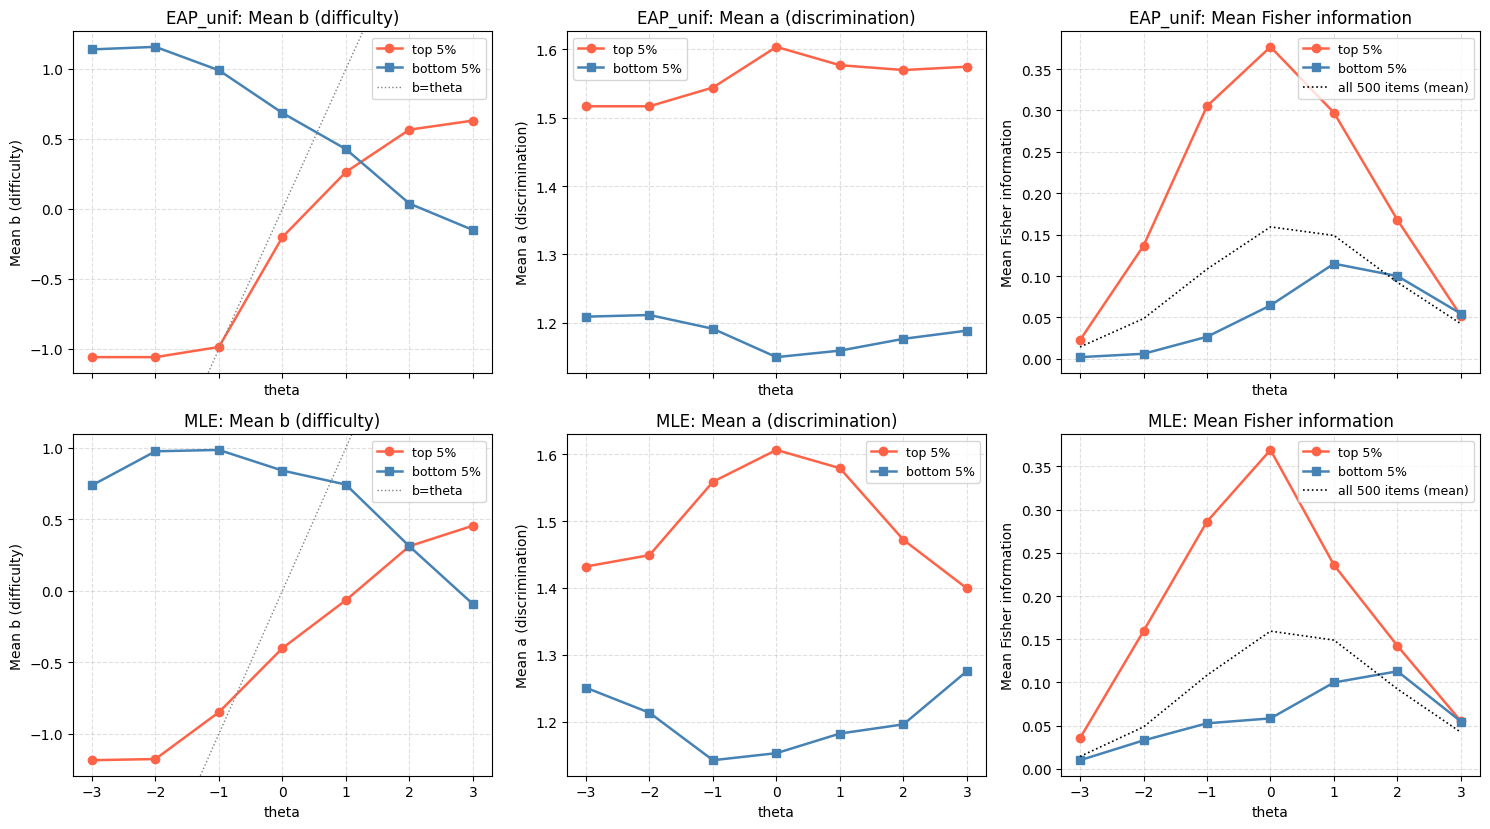

Saved: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP027/results/analysis_q_top_bottom_uncor_1_gamma_0.1.png


In [14]:
# Plot mean item parameters (a, b) and mean Fisher information of the
# top vs bottom 5% groups as a function of theta, one row per model.
metrics = [
    ("b_mean", "Mean b (difficulty)"),
    ("a_mean", "Mean a (discrimination)"),
    ("FI_mean", "Mean Fisher information"),
]
colors = {"top": "tomato", "bottom": "steelblue"}
markers = {"top": "o", "bottom": "s"}

figure, axes = plt.subplots(
    len(models), len(metrics), figsize=(15, 4.2 * len(models)), sharex=True
)
if len(models) == 1:
    axes = np.array([axes])

for row_idx, model_name in enumerate(models):
    for col_idx, (column, ylabel) in enumerate(metrics):
        axis = axes[row_idx, col_idx]
        subset = summary[summary["model"] == model_name]
        for group in ("top", "bottom"):
            data = subset[subset["group"] == group]
            axis.plot(
                data["theta"],
                data[column],
                marker=markers[group],
                color=colors[group],
                label=f"{group} {TOP_FRAC:.0%}",
                linewidth=1.8,
            )
        if column == "FI_mean":
            axis.plot(
                subset[subset["group"] == "top"]["theta"],
                subset[subset["group"] == "top"]["all_FI_mean"],
                color="black",
                linestyle=":",
                linewidth=1.2,
                label="all 500 items (mean)",
            )
        if column == "b_mean":
            axis.axline(
                (0, 0),
                slope=1,
                color="gray",
                linestyle=":",
                linewidth=1.0,
                label="b=theta",
            )
        axis.set_title(f"{model_name}: {ylabel}")
        axis.set_xlabel("theta")
        axis.set_ylabel(ylabel)
        axis.grid(True, linestyle="--", alpha=0.4)
        axis.legend(fontsize=9)

figure.tight_layout()
plot_path = (
    RESULTS_DIR / f"analysis_q_top_bottom_{BANK_TYPE}_{BANK_ID}_gamma_{GAMMA}.png"
)
figure.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved: {plot_path}")

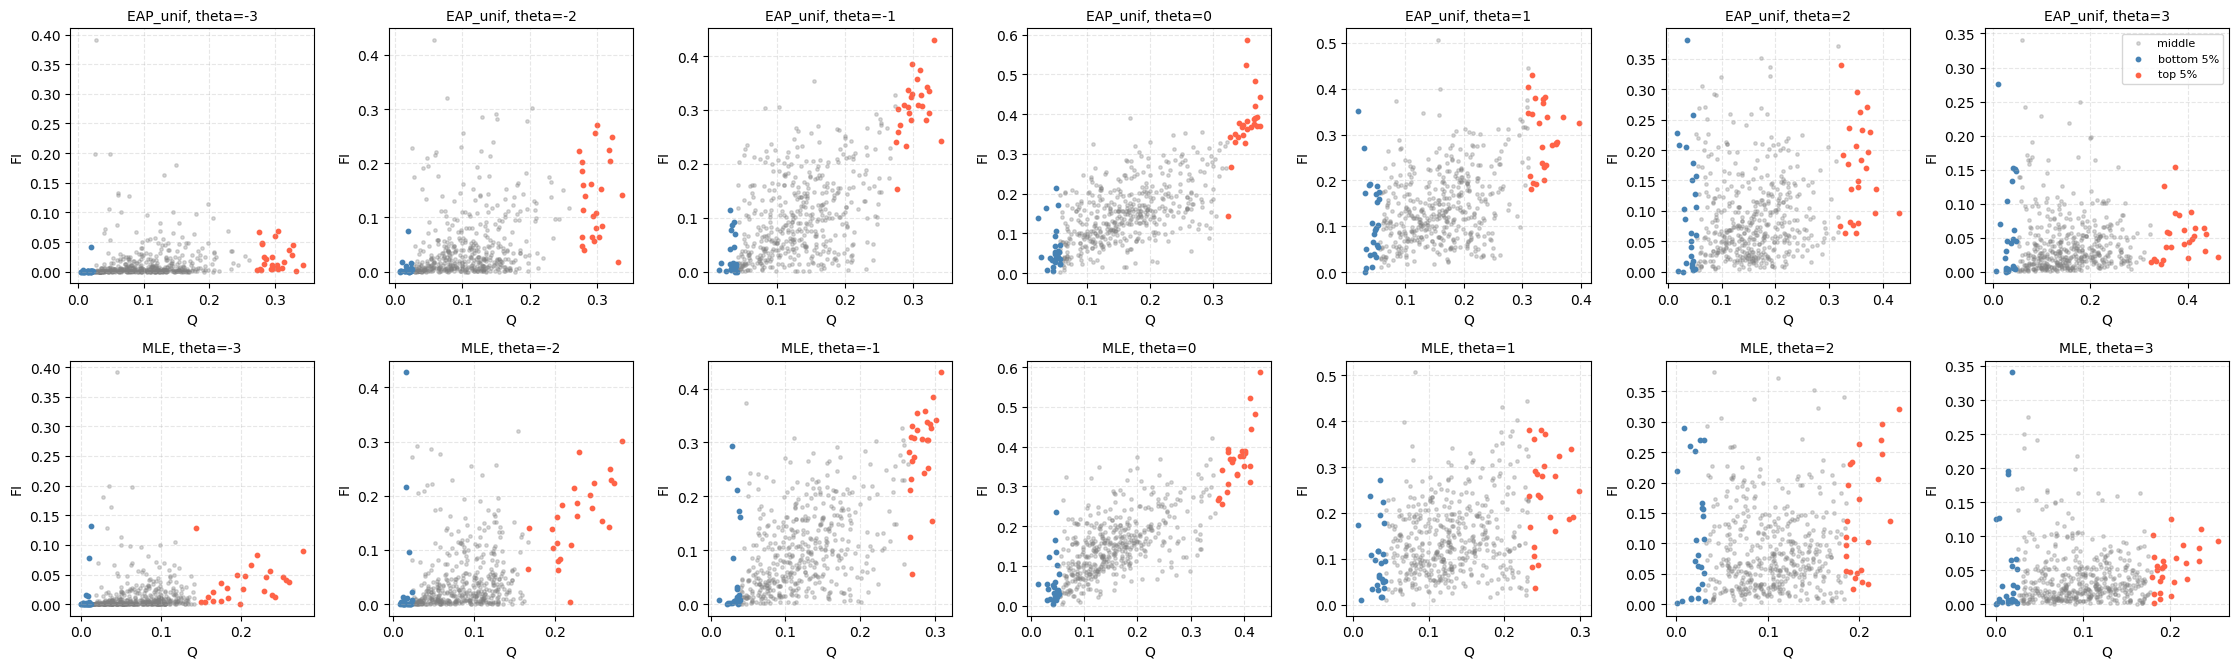

Saved: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP027/results/analysis_q_vs_fi_scatter_uncor_1_gamma_0.1.png


In [15]:
# Scatter of Fisher information vs Q value across all items, coloured by group.
# One column per theta, one row per model.
figure, axes = plt.subplots(
    len(models),
    len(THETAS),
    figsize=(3.2 * len(THETAS), 3.4 * len(models)),
    squeeze=False,
)
for row_idx, model_name in enumerate(models):
    for col_idx, theta in enumerate(THETAS):
        result = raw_by_model_theta[(model_name, theta)]
        q = result["q"]
        fi = result["fi"]
        top_idx = result["top_idx"]
        bottom_idx = result["bottom_idx"]
        mid_mask = np.ones_like(q, dtype=bool)
        mid_mask[top_idx] = False
        mid_mask[bottom_idx] = False

        axis = axes[row_idx, col_idx]
        axis.scatter(
            q[mid_mask], fi[mid_mask], s=6, alpha=0.3, color="gray", label="middle"
        )
        axis.scatter(
            q[bottom_idx],
            fi[bottom_idx],
            s=10,
            color="steelblue",
            label=f"bottom {TOP_FRAC:.0%}",
        )
        axis.scatter(
            q[top_idx],
            fi[top_idx],
            s=10,
            color="tomato",
            label=f"top {TOP_FRAC:.0%}",
        )
        axis.set_title(f"{model_name}, theta={theta:g}", fontsize=10)
        axis.set_xlabel("Q")
        axis.set_ylabel("FI")
        axis.grid(True, linestyle="--", alpha=0.3)
        if row_idx == 0 and col_idx == len(THETAS) - 1:
            axis.legend(fontsize=8, loc="best")

figure.tight_layout()
scatter_path = (
    RESULTS_DIR / f"analysis_q_vs_fi_scatter_{BANK_TYPE}_{BANK_ID}_gamma_{GAMMA}.png"
)
figure.savefig(scatter_path, dpi=150)
plt.show()
print(f"Saved: {scatter_path}")